# Transportation-Distance Relaxation of Stochastic Dominance

The exact empirical stochastic-dominance model requires the portfolio return distribution to second-order stochastically dominate the benchmark distribution. In the preceding analysis, this condition was feasible for almost every historical estimation window, but the resulting dominance relation frequently failed to persist during the subsequent holding period.

This notebook implements the transportation-distance relaxation proposed by Dentcheva and Yi. Instead of introducing a separate slack variable for every stochastic-dominance condition, the method measures the distance between the portfolio return distribution and the complete set of distributions that second-order stochastically dominate the benchmark.

Let

$$
A_2(Y)
=
\left\{
Z:Z\succeq_{(2)}Y
\right\}
$$

denote the set of random variables that second-order stochastically dominate the benchmark \(Y\). For a portfolio return \(G(w)\), its distance to the dominating set is

$$
\operatorname{dist}
\left(
G(w),A_2(Y)
\right)
=
\inf_{Z\in A_2(Y)}
W_1\left(G(w),Z\right),
$$

where \(W_1\) is the first-order Wasserstein, or optimal mass transportation, distance.

For second-order stochastic dominance, this distance has the explicit representation

$$
D(w)
=
\max
\left\{
0,\;
\sup_{\eta\in\mathbb{R}}
\left[
\mathbb{E}
\left[
(\eta-G(w))_+
\right]
-
\mathbb{E}
\left[
(\eta-Y)_+
\right]
\right]
\right\}.
$$

The quantity \(D(w)\) has the following interpretation:

* \(D(w)=0\) if the portfolio already second-order stochastically dominates the benchmark;
* \(D(w)>0\) measures the minimum transportation distance required to move the portfolio distribution into the SSD-dominating set;
* the maximizing threshold \(\eta\) identifies the largest difference between the portfolio and benchmark integrated distribution functions.

The relaxed portfolio problem is

$$
\min_w
\left\{
-\mathbb{E}[G(w)]
+
\alpha D(w)
\right\},
$$

subject to

$$
\mathbf{1}^{\top}w=1,
\qquad
w\geq0.
$$

Equivalently, the model maximizes

$$
\mathbb{E}[G(w)]-\alpha D(w).
$$

The parameter \(\alpha\) controls the trade-off between expected return and proximity to the set of distributions that dominate SPY. A small value prioritizes estimated return, whereas a sufficiently large value places greater emphasis on eliminating the stochastic-dominance violation.


In [39]:
from pathlib import Path

import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TRADING_DAYS = 252
ESTIMATION_YEARS = 3

BACKTEST_START_DATE = pd.Timestamp(
    "2010-04-12"
)

BENCHMARK_NAME = "SPY"
SOLVER = "CLARABEL"

DISTANCE_TOLERANCE = 1e-10

sns.set_theme(style="whitegrid")

In [40]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "etf_adjusted_close.csv"
)

prices = pd.read_csv(
    DATA_PATH,
    index_col="Date",
    parse_dates=["Date"],
).sort_index()

returns = (
    prices
    .pct_change(fill_method=None)
    .dropna()
)

assert BENCHMARK_NAME in returns.columns

# Continue excluding SPY from the decision
# universe for consistency with notebook 07.
asset_names = returns.columns.drop(
    BENCHMARK_NAME
)

backtest_start = returns.index[
    returns.index >= BACKTEST_START_DATE
][0]

backtest_end = returns.index.max()

print(
    "Return period:",
    returns.index.min(),
    "to",
    returns.index.max(),
)

print(
    "Backtest period:",
    backtest_start,
    "to",
    backtest_end,
)

print("Benchmark:", BENCHMARK_NAME)

print(
    "Investable assets:",
    asset_names.tolist(),
)

Return period: 2007-04-12 00:00:00 to 2020-04-01 00:00:00
Backtest period: 2010-04-12 00:00:00 to 2020-04-01 00:00:00
Benchmark: SPY
Investable assets: ['QQQ', 'IWM', 'EFA', 'EEM', 'IEF', 'TLT', 'LQD', 'HYG', 'GLD', 'DBC', 'VNQ']


In [41]:
requested_formation_date = pd.Timestamp(
    "2017-01-03"
)

formation_date = returns.index[
    returns.index
    >= requested_formation_date
][0]

estimation_start = (
    formation_date
    - pd.DateOffset(
        years=ESTIMATION_YEARS
    )
)

estimation_returns = returns.loc[
    (returns.index >= estimation_start)
    & (returns.index < formation_date)
].copy()

print("Formation date:", formation_date)

print(
    "Estimation period:",
    estimation_returns.index.min(),
    "to",
    estimation_returns.index.max(),
)

print(
    "Number of scenarios:",
    len(estimation_returns),
)

Formation date: 2017-01-03 00:00:00
Estimation period: 2014-01-03 00:00:00 to 2016-12-30 00:00:00
Number of scenarios: 755


In [42]:
scenario_return_matrix = (
    estimation_returns[asset_names]
    .to_numpy(dtype=float)
)

benchmark_return_vector = (
    estimation_returns[BENCHMARK_NAME]
    .to_numpy(dtype=float)
)

number_of_scenarios = (
    scenario_return_matrix.shape[0]
)

number_of_assets = (
    scenario_return_matrix.shape[1]
)

assert scenario_return_matrix.shape == (
    number_of_scenarios,
    number_of_assets,
)

assert benchmark_return_vector.shape == (
    number_of_scenarios,
)

assert np.isfinite(
    scenario_return_matrix
).all()

assert np.isfinite(
    benchmark_return_vector
).all()

print(
    "Scenario matrix shape:",
    scenario_return_matrix.shape,
)

print(
    "Benchmark vector shape:",
    benchmark_return_vector.shape,
)

Scenario matrix shape: (755, 11)
Benchmark vector shape: (755,)


In [43]:
def empirical_shortfall(
    return_vector,
    thresholds,
):
    """
    Calculate E[(eta - X)_+] for every eta
    in thresholds under equally likely
    empirical scenarios.
    """

    return_vector = np.asarray(
        return_vector,
        dtype=float,
    )

    thresholds = np.asarray(
        thresholds,
        dtype=float,
    )

    shortfall_values = np.maximum(
        thresholds[:, None]
        - return_vector[None, :],
        0.0,
    ).mean(axis=1)

    return shortfall_values

In [44]:
def empirical_transportation_distance(
    portfolio_return_vector,
    benchmark_return_vector,
):
    """
    Calculate

        D(X) = max{
            0,
            sup_eta [
                E[(eta - X)_+]
                - E[(eta - Y)_+]
            ]
        }

    for two equally weighted empirical
    return distributions.
    """

    portfolio_return_vector = np.asarray(
        portfolio_return_vector,
        dtype=float,
    )

    benchmark_return_vector = np.asarray(
        benchmark_return_vector,
        dtype=float,
    )

    if (
        len(portfolio_return_vector)
        != len(benchmark_return_vector)
    ):
        raise ValueError(
            "Portfolio and benchmark must "
            "contain the same number of scenarios."
        )

    # The difference between the two empirical
    # shortfall functions is piecewise linear.
    # Its maximum can be found at empirical
    # breakpoints.
    thresholds = np.unique(
        benchmark_return_vector
    )

    portfolio_shortfall = empirical_shortfall(
        portfolio_return_vector,
        thresholds,
    )

    benchmark_shortfall = empirical_shortfall(
        benchmark_return_vector,
        thresholds,
    )

    shortfall_gaps = (
        portfolio_shortfall
        - benchmark_shortfall
    )

    maximizing_position = np.argmax(
        shortfall_gaps
    )

    maximum_gap = shortfall_gaps[
        maximizing_position
    ]

    distance = max(
        0.0,
        maximum_gap,
    )

    maximizing_threshold = thresholds[
        maximizing_position
    ]

    return {
        "distance":
            distance,

        "maximizing_threshold":
            maximizing_threshold,

        "maximum_gap":
            maximum_gap,

        "thresholds":
            thresholds,

        "portfolio_shortfall":
            portfolio_shortfall,

        "benchmark_shortfall":
            benchmark_shortfall,

        "shortfall_gaps":
            shortfall_gaps,
    }

In [45]:
benchmark_self_test = (
    empirical_transportation_distance(
        portfolio_return_vector=
            benchmark_return_vector,

        benchmark_return_vector=
            benchmark_return_vector,
    )
)

print(
    "SPY-to-SPY distance:",
    benchmark_self_test["distance"],
)

assert np.isclose(
    benchmark_self_test["distance"],
    0.0,
    atol=DISTANCE_TOLERANCE,
)

SPY-to-SPY distance: 0.0


In [46]:
portfolio_weight_examples = {}

# Equal-weight portfolio
portfolio_weight_examples[
    "Equal Weight"
] = pd.Series(
    1 / number_of_assets,
    index=asset_names,
)

# 100% GLD
gld_weights = pd.Series(
    0.0,
    index=asset_names,
)

gld_weights["GLD"] = 1.0

portfolio_weight_examples[
    "100% GLD"
] = gld_weights

# 100% QQQ
qqq_weights = pd.Series(
    0.0,
    index=asset_names,
)

qqq_weights["QQQ"] = 1.0

portfolio_weight_examples[
    "100% QQQ"
] = qqq_weights


portfolio_weight_examples

{'Equal Weight': QQQ    0.090909
 IWM    0.090909
 EFA    0.090909
 EEM    0.090909
 IEF    0.090909
 TLT    0.090909
 LQD    0.090909
 HYG    0.090909
 GLD    0.090909
 DBC    0.090909
 VNQ    0.090909
 dtype: float64,
 '100% GLD': QQQ    0.0
 IWM    0.0
 EFA    0.0
 EEM    0.0
 IEF    0.0
 TLT    0.0
 LQD    0.0
 HYG    0.0
 GLD    1.0
 DBC    0.0
 VNQ    0.0
 dtype: float64,
 '100% QQQ': QQQ    1.0
 IWM    0.0
 EFA    0.0
 EEM    0.0
 IEF    0.0
 TLT    0.0
 LQD    0.0
 HYG    0.0
 GLD    0.0
 DBC    0.0
 VNQ    0.0
 dtype: float64}

In [47]:
distance_records = []

distance_results = {}

for portfolio_name, weights in (
    portfolio_weight_examples.items()
):
    portfolio_return_vector = (
        scenario_return_matrix
        @ weights.to_numpy()
    )

    distance_result = (
        empirical_transportation_distance(
            portfolio_return_vector=
                portfolio_return_vector,

            benchmark_return_vector=
                benchmark_return_vector,
        )
    )

    distance_results[
        portfolio_name
    ] = distance_result

    distance_records.append(
        {
            "Portfolio":
                portfolio_name,

            "Estimated Daily Return":
                portfolio_return_vector.mean(),

            "Transportation Distance":
                distance_result["distance"],

            "Maximizing Threshold":
                distance_result[
                    "maximizing_threshold"
                ],
        }
    )

distance_comparison = (
    pd.DataFrame(distance_records)
    .set_index("Portfolio")
)

display(
    distance_comparison.style.format(
        {
            "Estimated Daily Return":
                "{:.4%}",

            "Transportation Distance":
                "{:.4%}",

            "Maximizing Threshold":
                "{:.4%}",
        }
    )
)

,Estimated Daily Return,Transportation Distance,Maximizing Threshold
Portfolio,,,
Equal Weight,0.0138%,0.0243%,3.8394%
100% GLD,-0.0053%,0.0797%,0.5070%
100% QQQ,0.0504%,0.0568%,-0.0332%


In [48]:
benchmark_thresholds = np.unique(
    benchmark_return_vector
)

benchmark_shortfall_values = (
    empirical_shortfall(
        return_vector=
            benchmark_return_vector,

        thresholds=
            benchmark_thresholds,
    )
)

print(
    "Number of benchmark thresholds:",
    len(benchmark_thresholds),
)

Number of benchmark thresholds: 755


In [49]:
def transportation_distance_and_subgradient(
    weights,
    scenario_return_matrix,
    benchmark_return_vector,
    distance_tolerance=1e-12,
):
    """
    Calculate D(w), a maximizing threshold eta,
    and one subgradient of D at w.
    """

    weights = np.asarray(
        weights,
        dtype=float,
    ).reshape(-1)

    portfolio_return_vector = (
        scenario_return_matrix
        @ weights
    )

    distance_result = (
        empirical_transportation_distance(
            portfolio_return_vector=
                portfolio_return_vector,

            benchmark_return_vector=
                benchmark_return_vector,
        )
    )

    distance = distance_result[
        "distance"
    ]

    maximizing_threshold = distance_result[
        "maximizing_threshold"
    ]

    if distance <= distance_tolerance:
        subgradient = np.zeros_like(
            weights
        )
    else:
        # A valid hinge-loss subgradient:
        # derivative of (eta - r_s^T w)_+
        # is -r_s when r_s^T w < eta.
        below_threshold = (
            portfolio_return_vector
            < maximizing_threshold
        ).astype(float)

        subgradient = -(
            scenario_return_matrix.T
            @ below_threshold
        ) / len(portfolio_return_vector)

    return {
        "distance":
            distance,

        "subgradient":
            subgradient,

        "maximizing_threshold":
            maximizing_threshold,

        "portfolio_returns":
            portfolio_return_vector,

        "maximum_gap":
            distance_result["maximum_gap"],
    }

In [50]:
ALPHA_VALUES = [
    0.01,
    0.03,
    0.05,
    0.1,
    0.2,
    0.5,
    1.0,
    2.0,
    5.0,
]

In [51]:
rng = np.random.default_rng(42)

test_weights = np.repeat(
    1 / number_of_assets,
    number_of_assets,
)

test_result = (
    transportation_distance_and_subgradient(
        weights=
            test_weights,

        scenario_return_matrix=
            scenario_return_matrix,

        benchmark_return_vector=
            benchmark_return_vector,
    )
)

test_distance = test_result[
    "distance"
]

test_subgradient = test_result[
    "subgradient"
]

subgradient_violations = []

for _ in range(50):

    comparison_weights = rng.dirichlet(
        np.ones(number_of_assets)
    )

    comparison_result = (
        transportation_distance_and_subgradient(
            weights=
                comparison_weights,

            scenario_return_matrix=
                scenario_return_matrix,

            benchmark_return_vector=
                benchmark_return_vector,
        )
    )

    actual_distance = comparison_result[
        "distance"
    ]

    supporting_value = (
        test_distance
        + test_subgradient
        @ (
            comparison_weights
            - test_weights
        )
    )

    subgradient_violations.append(
        supporting_value
        - actual_distance
    )

maximum_subgradient_violation = max(
    subgradient_violations
)

print(
    "Distance at test point:",
    test_distance,
)

print(
    "Max supporting-hyperplane violation:",
    f"{maximum_subgradient_violation:.3e}",
)

assert (
    maximum_subgradient_violation
    <= 1e-9
)

Distance at test point: 0.00024326362138512442
Max supporting-hyperplane violation: 5.638e-18


In [52]:
def solve_transportation_relaxation_cp(
    alpha,
    scenario_return_matrix,
    benchmark_return_vector,
    asset_names,
    solver="CLARABEL",
    tolerance=1e-8,
    max_iterations=100,
    initial_weights=None,
    verbose=False,
):
    """
    Solve

        min -E[G(w)] + alpha * D(w)

    using the Transportation Distance
    Relaxation cutting-plane method.
    """

    if alpha <= 0:
        raise ValueError(
            "alpha must be strictly positive."
        )

    number_of_scenarios = (
        scenario_return_matrix.shape[0]
    )

    number_of_assets = (
        scenario_return_matrix.shape[1]
    )

    estimated_asset_means = (
        scenario_return_matrix.mean(axis=0)
    )

    if initial_weights is None:
        current_weights = np.repeat(
            1 / number_of_assets,
            number_of_assets,
        )
    else:
        current_weights = np.asarray(
            initial_weights,
            dtype=float,
        ).reshape(-1)

        current_weights = np.maximum(
            current_weights,
            0,
        )

        current_weights /= (
            current_weights.sum()
        )

    cuts = []
    iteration_records = []

    # Initial supporting cut at w^0.
    initial_distance_result = (
        transportation_distance_and_subgradient(
            weights=
                current_weights,

            scenario_return_matrix=
                scenario_return_matrix,

            benchmark_return_vector=
                benchmark_return_vector,
        )
    )

    cuts.append(
        {
            "reference_weights":
                current_weights.copy(),

            "distance":
                initial_distance_result[
                    "distance"
                ],

            "subgradient":
                initial_distance_result[
                    "subgradient"
                ].copy(),
        }
    )

    for iteration in range(
        1,
        max_iterations + 1,
    ):
        weight_variable = cp.Variable(
            number_of_assets,
            name="weights",
        )

        distance_approximation = cp.Variable(
            nonneg=True,
            name="distance_approximation",
        )

        constraints = [
            cp.sum(weight_variable) == 1,
            weight_variable >= 0,
        ]

        for cut in cuts:
            reference_weights = cut[
                "reference_weights"
            ]

            reference_distance = cut[
                "distance"
            ]

            reference_subgradient = cut[
                "subgradient"
            ]

            constraints.append(
                reference_distance
                + reference_subgradient
                @ (
                    weight_variable
                    - reference_weights
                )
                <= distance_approximation
            )

        master_objective = cp.Minimize(
            -estimated_asset_means
            @ weight_variable
            + alpha
            * distance_approximation
        )

        master_problem = cp.Problem(
            master_objective,
            constraints,
        )

        master_problem.solve(
            solver=solver
        )

        if master_problem.status not in [
            "optimal",
            "optimal_inaccurate",
        ]:
            return {
                "status":
                    master_problem.status,

                "weights":
                    None,

                "iteration_history":
                    pd.DataFrame(
                        iteration_records
                    ),
            }

        candidate_weights = np.asarray(
            weight_variable.value
        ).reshape(-1)

        candidate_distance_result = (
            transportation_distance_and_subgradient(
                weights=
                    candidate_weights,

                scenario_return_matrix=
                    scenario_return_matrix,

                benchmark_return_vector=
                    benchmark_return_vector,
            )
        )

        true_distance = (
            candidate_distance_result[
                "distance"
            ]
        )

        approximate_distance = float(
            distance_approximation.value
        )

        approximation_gap = (
            true_distance
            - approximate_distance
        )

        estimated_return = (
            estimated_asset_means
            @ candidate_weights
        )

        true_objective = (
            -estimated_return
            + alpha * true_distance
        )

        master_lower_bound = (
            master_problem.value
        )

        iteration_records.append(
            {
                "Iteration":
                    iteration,

                "Number of Cuts":
                    len(cuts),

                "Estimated Daily Return":
                    estimated_return,

                "Approximate Distance":
                    approximate_distance,

                "True Distance":
                    true_distance,

                "Approximation Gap":
                    approximation_gap,

                "Worst-Violation Threshold":
                    candidate_distance_result[
                        "maximizing_threshold"
                    ],

                "Master Lower Bound":
                    master_lower_bound,

                "True Objective":
                    true_objective,
            }
        )

        if verbose:
            print(
                f"Iteration {iteration:>2}: "
                f"cuts={len(cuts):>2}, "
                f"D_hat={approximate_distance:.10f}, "
                f"D={true_distance:.10f}, "
                f"gap={approximation_gap:.3e}"
            )

        if approximation_gap <= tolerance:

            final_weights = np.maximum(
                candidate_weights,
                0,
            )

            final_weights /= (
                final_weights.sum()
            )

            # Recalculate after numerical cleaning.
            final_distance_result = (
                transportation_distance_and_subgradient(
                    weights=
                        final_weights,

                    scenario_return_matrix=
                        scenario_return_matrix,

                    benchmark_return_vector=
                        benchmark_return_vector,
                )
            )

            final_return = (
                estimated_asset_means
                @ final_weights
            )

            final_distance = (
                final_distance_result[
                    "distance"
                ]
            )

            return {
                "status":
                    master_problem.status,

                "weights":
                    pd.Series(
                        final_weights,
                        index=asset_names,
                        name="Weight",
                    ),

                "estimated_daily_return":
                    final_return,

                "transportation_distance":
                    final_distance,

                "maximizing_threshold":
                    final_distance_result[
                        "maximizing_threshold"
                    ],

                "objective_value":
                    (
                        final_return
                        - alpha * final_distance
                    ),

                "number_of_iterations":
                    iteration,

                "number_of_cuts":
                    len(cuts),

                "iteration_history":
                    pd.DataFrame(
                        iteration_records
                    ),
            }

        cuts.append(
            {
                "reference_weights":
                    candidate_weights.copy(),

                "distance":
                    true_distance,

                "subgradient":
                    candidate_distance_result[
                        "subgradient"
                    ].copy(),
            }
        )

    return {
        "status":
            "maximum_iterations",

        "weights":
            None,

        "iteration_history":
            pd.DataFrame(
                iteration_records
            ),
    }

In [53]:
test_alpha = 0.5

test_relaxation_result = (
    solve_transportation_relaxation_cp(
        alpha=
            test_alpha,

        scenario_return_matrix=
            scenario_return_matrix,

        benchmark_return_vector=
            benchmark_return_vector,

        asset_names=
            asset_names,

        solver=
            SOLVER,

        tolerance=
            1e-5,

        max_iterations=
            100,

        verbose=
            True,
    )
)

Iteration  1: cuts= 1, D_hat=0.0000000000, D=0.0005233767, gap=5.234e-04
Iteration  2: cuts= 2, D_hat=0.0000000000, D=0.0001625070, gap=1.625e-04
Iteration  3: cuts= 3, D_hat=0.0000000000, D=0.0000450143, gap=4.501e-05
Iteration  4: cuts= 4, D_hat=0.0000000000, D=0.0000145561, gap=1.456e-05
Iteration  5: cuts= 5, D_hat=0.0000000000, D=0.0000058404, gap=5.840e-06


In [54]:
print(
    "Status:",
    test_relaxation_result["status"],
)

print(
    "Iterations:",
    test_relaxation_result[
        "number_of_iterations"
    ],
)

print(
    "Number of cuts:",
    test_relaxation_result[
        "number_of_cuts"
    ],
)

print(
    "Estimated daily return:",
    test_relaxation_result[
        "estimated_daily_return"
    ],
)

print(
    "Transportation distance:",
    test_relaxation_result[
        "transportation_distance"
    ],
)

print(
    "Worst-violation threshold:",
    test_relaxation_result[
        "maximizing_threshold"
    ],
)

display(
    test_relaxation_result[
        "weights"
    ]
    .sort_values(ascending=False)
    .to_frame()
    .style.format("{:.2%}")
)

Status: optimal
Iterations: 5
Number of cuts: 5
Estimated daily return: 0.0005182923685076403
Transportation distance: 5.840399873905267e-06
Worst-violation threshold: -0.001181204388295387


,Weight
VNQ,63.62%
QQQ,31.60%
TLT,4.78%
IWM,0.00%
LQD,0.00%
IEF,0.00%
HYG,0.00%
GLD,0.00%
EFA,0.00%
EEM,0.00%


In [55]:
test_relaxation_result[
    "iteration_history"
]

,Iteration,Number of Cuts,Estimated Daily Return,Approximate Distance,True Distance,Approximation Gap,Worst-Violation Threshold,Master Lower Bound,True Objective
0,1,1,0.000539,0.0,0.000523,0.000523,-0.000714,-0.000539,-0.000277
1,2,2,0.000527,0.0,0.000163,0.000163,-0.000869,-0.000527,-0.000446
2,3,3,0.000518,0.0,0.000045,0.000045,-0.001148,-0.000518,-0.000496
3,4,4,0.000518,0.0,0.000015,0.000015,-0.001254,-0.000518,-0.000511
4,5,5,0.000518,0.0,0.000006,0.000006,-0.001181,-0.000518,-0.000515


In [56]:
ALPHA_VALUES = [
    0.001,
    0.005,
    0.01,
    0.02,
    0.03,
    0.04,
    0.05,
    0.10,
    0.50,
]

In [57]:
relaxation_results = {}
relaxation_records = []

for alpha in ALPHA_VALUES:

    result = (
        solve_transportation_relaxation_cp(
            alpha=
                alpha,

            scenario_return_matrix=
                scenario_return_matrix,

            benchmark_return_vector=
                benchmark_return_vector,

            asset_names=
                asset_names,

            solver=
                SOLVER,

            tolerance=
                1e-8,

            max_iterations=
                100,

            verbose=
                False,
        )
    )

    relaxation_results[
        alpha
    ] = result

    if result["weights"] is None:
        print(
            f"alpha={alpha}: "
            f"{result['status']}"
        )
        continue

    relaxation_records.append(
        {
            "Alpha":
                alpha,

            "Estimated Daily Return":
                result[
                    "estimated_daily_return"
                ],

            "Transportation Distance":
                result[
                    "transportation_distance"
                ],

            "Penalized Utility":
                result[
                    "objective_value"
                ],

            "Iterations":
                result[
                    "number_of_iterations"
                ],

            "Maximum Weight":
                result[
                    "weights"
                ].max(),

            "Largest Holding":
                result[
                    "weights"
                ].idxmax(),
        }
    )

relaxation_summary = (
    pd.DataFrame(relaxation_records)
    .set_index("Alpha")
)

display(
    relaxation_summary.style.format(
        {
            "Estimated Daily Return":
                "{:.4%}",

            "Transportation Distance":
                "{:.4%}",

            "Penalized Utility":
                "{:.6f}",

            "Maximum Weight":
                "{:.2%}",
        }
    )
)

,Estimated Daily Return,Transportation Distance,Penalized Utility,Iterations,Maximum Weight,Largest Holding
Alpha,,,,,,
0.001000,0.0539%,0.0523%,0.000538,2,100.00%,VNQ
0.005000,0.0539%,0.0523%,0.000536,2,100.00%,VNQ
0.010000,0.0539%,0.0523%,0.000533,2,100.00%,VNQ
0.020000,0.0539%,0.0523%,0.000528,2,99.99%,VNQ
0.030000,0.0533%,0.0314%,0.000524,9,84.68%,VNQ
0.040000,0.0530%,0.0233%,0.000521,8,76.55%,VNQ
0.050000,0.0528%,0.0171%,0.000519,9,68.57%,VNQ
0.100000,0.0518%,0.0000%,0.000518,12,62.28%,VNQ
0.500000,0.0518%,0.0000%,0.000518,12,62.28%,VNQ


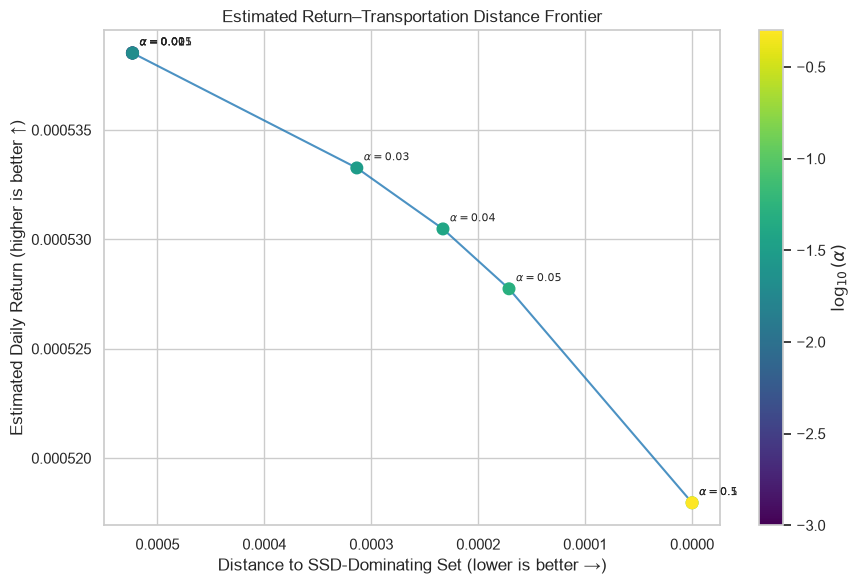

In [58]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

frontier_data = (
    relaxation_summary
    .sort_values(
        "Transportation Distance",
        ascending=False,
    )
)

scatter = ax.scatter(
    frontier_data[
        "Transportation Distance"
    ],
    frontier_data[
        "Estimated Daily Return"
    ],
    c=np.log10(
        frontier_data.index.to_numpy()
    ),
    cmap="viridis",
    s=70,
    zorder=3,
)

ax.plot(
    frontier_data[
        "Transportation Distance"
    ],
    frontier_data[
        "Estimated Daily Return"
    ],
    color="tab:blue",
    linewidth=1.5,
    alpha=0.8,
)

for alpha, row in (
    frontier_data.iterrows()
):
    ax.annotate(
        rf"$\alpha={alpha:g}$",
        (
            row[
                "Transportation Distance"
            ],
            row[
                "Estimated Daily Return"
            ],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.invert_xaxis()

ax.set_title(
    "Estimated Return–Transportation Distance Frontier"
)

ax.set_xlabel(
    "Distance to SSD-Dominating Set "
    "(lower is better →)"
)

ax.set_ylabel(
    "Estimated Daily Return "
    "(higher is better ↑)"
)

colorbar = plt.colorbar(
    scatter,
    ax=ax,
)

colorbar.set_label(
    r"$\log_{10}(\alpha)$"
)

plt.tight_layout()
plt.show()

### Estimated Return–Transportation Distance Frontier

The figure illustrates the trade-off between estimated portfolio return and
the transportation distance to the set of distributions that second-order
stochastically dominate SPY.

The horizontal axis is reversed so that more desirable portfolios appear
farther to the right: moving right corresponds to a smaller violation of the
SSD relation. The vertical axis reports the estimated daily return, with higher
values being preferable.

For very small penalty parameters, approximately
$\alpha \leq 0.02$, the return component dominates the objective. The optimizer
therefore selects the highest-estimated-return portfolio, even though its
distribution remains relatively far from the SSD-dominating set.

The interval from approximately $\alpha=0.03$ to $\alpha=0.05$ forms the main
trade-off region. Within this range, increasing $\alpha$ progressively reduces
the transportation distance while sacrificing only part of the estimated
return. These intermediate solutions represent relaxed stochastic-dominance
portfolios rather than either unrestricted return maximization or exact SSD.

At approximately $\alpha=0.1$, the transportation distance reaches zero.
Consequently, the estimated portfolio-return distribution belongs to the set
of distributions that second-order stochastically dominate the benchmark.
Increasing the penalty from $\alpha=0.1$ to $\alpha=0.5$ produces the same
solution, indicating that the model has entered an exact-penalty region.

The economically interesting candidates are therefore located near the bends
of the frontier. In particular, $\alpha=0.03$ to $\alpha=0.05$ provides
meaningful relaxed solutions, while $\alpha=0.1$ represents the estimated
exact-SSD solution. Whether these in-sample improvements persist out of sample
must be evaluated through the rolling monthly backtest.

In [59]:
BACKTEST_ALPHAS = [
    0.001,
    0.03,
    0.04,
    0.05,
    0.10,
]

formation_dates = (
    returns.loc[
        returns.index >= backtest_start
    ]
    .groupby(
        returns.loc[
            returns.index >= backtest_start
        ].index.to_period("M")
    )
    .head(1)
    .index
)

rolling_weights = {
    alpha: pd.DataFrame(
        index=formation_dates,
        columns=asset_names,
        dtype=float,
    )
    for alpha in BACKTEST_ALPHAS
}

rolling_daily_returns = {
    alpha: []
    for alpha in BACKTEST_ALPHAS
}

rolling_monthly_diagnostics = {
    alpha: []
    for alpha in BACKTEST_ALPHAS
}

print(
    "Number of formation dates:",
    len(formation_dates),
)

print(
    "First formation date:",
    formation_dates[0],
)

print(
    "Last formation date:",
    formation_dates[-1],
)

Number of formation dates: 121
First formation date: 2010-04-12 00:00:00
Last formation date: 2020-04-01 00:00:00


In [60]:
for formation_index, formation_date in enumerate(
    formation_dates
):
    if formation_index < len(formation_dates) - 1:
        next_formation_date = formation_dates[
            formation_index + 1
        ]

        realized_returns = returns.loc[
            (returns.index >= formation_date)
            & (returns.index < next_formation_date)
        ].copy()

    else:
        next_formation_date = (
            backtest_end
            + pd.Timedelta(days=1)
        )

        realized_returns = returns.loc[
            (returns.index >= formation_date)
            & (returns.index <= backtest_end)
        ].copy()

    estimation_start = (
        formation_date
        - pd.DateOffset(
            years=ESTIMATION_YEARS
        )
    )

    estimation_returns = returns.loc[
        (returns.index >= estimation_start)
        & (returns.index < formation_date)
    ].copy()

    scenario_return_matrix = (
        estimation_returns[asset_names]
        .to_numpy(dtype=float)
    )

    benchmark_return_vector = (
        estimation_returns[BENCHMARK_NAME]
        .to_numpy(dtype=float)
    )

    realized_scenario_matrix = (
        realized_returns[asset_names]
        .to_numpy(dtype=float)
    )

    realized_benchmark_vector = (
        realized_returns[BENCHMARK_NAME]
        .to_numpy(dtype=float)
    )

    for alpha in BACKTEST_ALPHAS:

        solution = (
            solve_transportation_relaxation_cp(
                alpha=alpha,

                scenario_return_matrix=
                    scenario_return_matrix,

                benchmark_return_vector=
                    benchmark_return_vector,

                asset_names=
                    asset_names,

                solver=
                    SOLVER,

                tolerance=
                    1e-8,

                max_iterations=
                    100,

                verbose=
                    False,
            )
        )

        if solution["weights"] is None:
            print(
                f"Failed: "
                f"date={formation_date.date()}, "
                f"alpha={alpha:g}, "
                f"status={solution['status']}"
            )
            continue

        optimized_weights = solution[
            "weights"
        ]

        rolling_weights[alpha].loc[
            formation_date
        ] = optimized_weights

        portfolio_realized_returns = pd.Series(
            (
                realized_scenario_matrix
                @ optimized_weights.to_numpy()
            ),
            index=realized_returns.index,
            name=(
                f"Relaxed_SSD_alpha_"
                f"{alpha:g}"
            ),
        )

        rolling_daily_returns[alpha].append(
            portfolio_realized_returns
        )

        realized_distance_result = (
            empirical_transportation_distance(
                portfolio_return_vector=
                    portfolio_realized_returns
                    .to_numpy(),

                benchmark_return_vector=
                    realized_benchmark_vector,
            )
        )

        realized_distance = (
            realized_distance_result[
                "distance"
            ]
        )

        realized_threshold = (
            realized_distance_result[
                "maximizing_threshold"
            ]
        )

        rolling_monthly_diagnostics[
            alpha
        ].append(
            {
                "Formation Date":
                    formation_date,

                "Next Formation Date":
                    next_formation_date,

                "Number of Estimation Scenarios":
                    len(estimation_returns),

                "Number of Realized Observations":
                    len(realized_returns),

                "Estimated Daily Return":
                    solution[
                        "estimated_daily_return"
                    ],

                "Estimated Distance":
                    solution[
                        "transportation_distance"
                    ],

                "Realized Portfolio Daily Return":
                    portfolio_realized_returns
                    .mean(),

                "Realized SPY Daily Return":
                    realized_benchmark_vector
                    .mean(),

                "Realized Distance":
                    realized_distance,

                "Realized Maximizing Threshold":
                    realized_threshold,

                "Realized Exact SSD":
                    realized_distance
                    <= DISTANCE_TOLERANCE,

                "Maximum Weight":
                    optimized_weights.max(),

                "Largest Holding":
                    optimized_weights.idxmax(),

                "Number of Iterations":
                    solution[
                        "number_of_iterations"
                    ],
            }
        )

    if (
        formation_index % 12 == 0
        or formation_index
        == len(formation_dates) - 1
    ):
        print(
            f"Completed "
            f"{formation_index + 1} / "
            f"{len(formation_dates)} months"
        )

Completed 1 / 121 months
Completed 13 / 121 months
Completed 25 / 121 months
Completed 37 / 121 months
Completed 49 / 121 months
Completed 61 / 121 months
Completed 73 / 121 months
Completed 85 / 121 months
Completed 97 / 121 months
Completed 109 / 121 months
Completed 121 / 121 months


In [61]:
relaxed_ssd_returns = pd.concat(
    {
        (
            f"Relaxed_SSD_alpha_"
            f"{alpha:g}"
        ): pd.concat(
            rolling_daily_returns[alpha]
        ).sort_index()

        for alpha in BACKTEST_ALPHAS
    },
    axis=1,
)

relaxed_ssd_returns[
    BENCHMARK_NAME
] = returns.loc[
    relaxed_ssd_returns.index,
    BENCHMARK_NAME,
]

rolling_diagnostics = {
    alpha: (
        pd.DataFrame(
            rolling_monthly_diagnostics[
                alpha
            ]
        )
        .set_index("Formation Date")
        .sort_index()
    )
    for alpha in BACKTEST_ALPHAS
}

print(
    "Realized return period:",
    relaxed_ssd_returns.index.min(),
    "to",
    relaxed_ssd_returns.index.max(),
)

print(
    "Return matrix shape:",
    relaxed_ssd_returns.shape,
)

display(
    relaxed_ssd_returns.head()
)

Realized return period: 2010-04-12 00:00:00 to 2020-04-01 00:00:00
Return matrix shape: (2512, 6)


,Relaxed_SSD_alpha_0.001,Relaxed_SSD_alpha_0.03,Relaxed_SSD_alpha_0.04,Relaxed_SSD_alpha_0.05,Relaxed_SSD_alpha_0.1,SPY
Date,,,,,,
2010-04-12,-0.005544,-0.005544,-0.005544,-0.005544,-0.005544,0.001589
2010-04-13,-0.002832,-0.002832,-0.002832,-0.002832,-0.002832,0.000752
2010-04-14,0.003017,0.003017,0.003017,0.003017,0.003017,0.011349
2010-04-15,0.005485,0.005485,0.005485,0.005485,0.005485,0.000825
2010-04-16,-0.021205,-0.021205,-0.021205,-0.021205,-0.021205,-0.015912


In [62]:
diagnostic_records = []

for alpha in BACKTEST_ALPHAS:

    diagnostics = rolling_diagnostics[
        alpha
    ]

    # Exclude the final one-day April 2020
    # segment from monthly distribution tests.
    comparable_months = diagnostics.loc[
        diagnostics[
            "Number of Realized Observations"
        ] >= 10
    ]

    diagnostic_records.append(
        {
            "Alpha":
                alpha,

            "Evaluated Months":
                len(comparable_months),

            "Average Estimated Daily Return":
                comparable_months[
                    "Estimated Daily Return"
                ].mean(),

            "Average Estimated Distance":
                comparable_months[
                    "Estimated Distance"
                ].mean(),

            "Average Realized Daily Return":
                comparable_months[
                    "Realized Portfolio Daily Return"
                ].mean(),

            "Average Realized Distance":
                comparable_months[
                    "Realized Distance"
                ].mean(),

            "Realized Exact SSD Rate":
                comparable_months[
                    "Realized Exact SSD"
                ].mean(),

            "Average Maximum Weight":
                comparable_months[
                    "Maximum Weight"
                ].mean(),

            "Average Number of Iterations":
                comparable_months[
                    "Number of Iterations"
                ].mean(),
        }
    )

rolling_diagnostic_summary = (
    pd.DataFrame(
        diagnostic_records
    )
    .set_index("Alpha")
)

display(
    rolling_diagnostic_summary.style.format(
        {
            "Average Estimated Daily Return":
                "{:.4%}",

            "Average Estimated Distance":
                "{:.4%}",

            "Average Realized Daily Return":
                "{:.4%}",

            "Average Realized Distance":
                "{:.4%}",

            "Realized Exact SSD Rate":
                "{:.2%}",

            "Average Maximum Weight":
                "{:.2%}",

            "Average Number of Iterations":
                "{:.2f}",
        }
    )
)

,Evaluated Months,Average Estimated Daily Return,Average Estimated Distance,Average Realized Daily Return,Average Realized Distance,Realized Exact SSD Rate,Average Maximum Weight,Average Number of Iterations
Alpha,,,,,,,,
0.001000,120,0.0805%,0.0912%,0.0659%,0.0969%,11.67%,100.00%,1.87
0.030000,120,0.0801%,0.0676%,0.0694%,0.0930%,14.17%,96.54%,2.52
0.040000,120,0.0799%,0.0622%,0.0675%,0.0925%,15.00%,95.64%,2.68
0.050000,120,0.0796%,0.0561%,0.0657%,0.0927%,15.00%,94.80%,2.95
0.100000,120,0.0779%,0.0329%,0.0646%,0.0860%,19.17%,90.77%,4.00


In [63]:
TAIL_PROBABILITIES = [
    0.05,
    0.10,
    0.15,
]


def empirical_cvar_loss(
    return_values,
    tail_probability,
):
    """
    Empirical CVaR expressed as a positive loss.

    tail_probability = 0.05 means the
    average loss among the worst 5% of returns.
    """

    return_values = np.asarray(
        return_values,
        dtype=float,
    )

    var_threshold = np.quantile(
        return_values,
        tail_probability,
    )

    tail_returns = return_values[
        return_values <= var_threshold
    ]

    return -tail_returns.mean()

In [64]:
rolling_risk_records = []

for formation_position, formation_date in enumerate(
    formation_dates[:-1]
):
    next_formation_date = formation_dates[
        formation_position + 1
    ]

    estimation_start = (
        formation_date
        - pd.DateOffset(
            years=ESTIMATION_YEARS
        )
    )

    estimation_returns = returns.loc[
        (returns.index >= estimation_start)
        & (returns.index < formation_date)
    ]

    realized_returns = returns.loc[
        (returns.index >= formation_date)
        & (returns.index < next_formation_date)
    ]

    for alpha in BACKTEST_ALPHAS:

        optimized_weights = (
            rolling_weights[alpha]
            .loc[formation_date]
            .to_numpy(dtype=float)
        )

        if not np.isfinite(
            optimized_weights
        ).all():
            continue

        estimated_portfolio_returns = (
            estimation_returns[asset_names]
            .to_numpy(dtype=float)
            @ optimized_weights
        )

        realized_portfolio_returns = (
            realized_returns[asset_names]
            .to_numpy(dtype=float)
            @ optimized_weights
        )

        risk_record = {
            "Formation Date":
                formation_date,

            "Strategy":
                (
                    f"Relaxed_SSD_alpha_"
                    f"{alpha:g}"
                ),

            "Estimated Annualized Variance":
                (
                    np.var(
                        estimated_portfolio_returns,
                        ddof=1,
                    )
                    * TRADING_DAYS
                ),

            "Realized Annualized Variance":
                (
                    np.var(
                        realized_portfolio_returns,
                        ddof=1,
                    )
                    * TRADING_DAYS
                ),
        }

        for tail_probability in (
            TAIL_PROBABILITIES
        ):
            tail_label = (
                f"{tail_probability:.0%}"
            )

            risk_record[
                (
                    f"Estimated CVaR "
                    f"(Worst {tail_label})"
                )
            ] = empirical_cvar_loss(
                estimated_portfolio_returns,
                tail_probability,
            )

            risk_record[
                (
                    f"Realized CVaR "
                    f"(Worst {tail_label})"
                )
            ] = empirical_cvar_loss(
                realized_portfolio_returns,
                tail_probability,
            )

        rolling_risk_records.append(
            risk_record
        )

    # Add SPY using exactly the same
    # estimation and realization windows.
    estimated_spy_returns = (
        estimation_returns[
            BENCHMARK_NAME
        ]
        .to_numpy(dtype=float)
    )

    realized_spy_returns = (
        realized_returns[
            BENCHMARK_NAME
        ]
        .to_numpy(dtype=float)
    )

    spy_risk_record = {
        "Formation Date":
            formation_date,

        "Strategy":
            BENCHMARK_NAME,

        "Estimated Annualized Variance":
            (
                np.var(
                    estimated_spy_returns,
                    ddof=1,
                )
                * TRADING_DAYS
            ),

        "Realized Annualized Variance":
            (
                np.var(
                    realized_spy_returns,
                    ddof=1,
                )
                * TRADING_DAYS
            ),
    }

    for tail_probability in (
        TAIL_PROBABILITIES
    ):
        tail_label = (
            f"{tail_probability:.0%}"
        )

        spy_risk_record[
            (
                f"Estimated CVaR "
                f"(Worst {tail_label})"
            )
        ] = empirical_cvar_loss(
            estimated_spy_returns,
            tail_probability,
        )

        spy_risk_record[
            (
                f"Realized CVaR "
                f"(Worst {tail_label})"
            )
        ] = empirical_cvar_loss(
            realized_spy_returns,
            tail_probability,
        )

    rolling_risk_records.append(
        spy_risk_record
    )

rolling_risk_detail = pd.DataFrame(
    rolling_risk_records
)

print(
    "Monthly risk records:",
    rolling_risk_detail.shape,
)

Monthly risk records: (720, 10)


In [65]:
risk_metric_columns = [
    "Estimated CVaR (Worst 5%)",
    "Realized CVaR (Worst 5%)",
    "Estimated CVaR (Worst 10%)",
    "Realized CVaR (Worst 10%)",
    "Estimated CVaR (Worst 15%)",
    "Realized CVaR (Worst 15%)",
    "Estimated Annualized Variance",
    "Realized Annualized Variance",
]

rolling_risk_summary = (
    rolling_risk_detail
    .groupby("Strategy")[
        risk_metric_columns
    ]
    .mean()
)

maximum_drawdowns = {}

for strategy_name in (
    relaxed_ssd_returns.columns
):
    strategy_returns = (
        relaxed_ssd_returns[
            strategy_name
        ]
        .dropna()
        .astype(float)
    )

    wealth = (
        1 + strategy_returns
    ).cumprod()

    running_peak = (
        wealth
        .cummax()
        .clip(lower=1.0)
    )

    drawdown = (
        wealth
        / running_peak
        - 1
    )

    maximum_drawdowns[
        strategy_name
    ] = drawdown.min()

rolling_risk_summary[
    "Maximum Realized Drawdown"
] = pd.Series(
    maximum_drawdowns
)

strategy_order = [
    (
        f"Relaxed_SSD_alpha_"
        f"{alpha:g}"
    )
    for alpha in BACKTEST_ALPHAS
] + [
    BENCHMARK_NAME
]

rolling_risk_summary = (
    rolling_risk_summary
    .reindex(strategy_order)
)

display(
    rolling_risk_summary.style.format(
        {
            "Estimated CVaR (Worst 5%)":
                "{:.2%}",

            "Realized CVaR (Worst 5%)":
                "{:.2%}",

            "Estimated CVaR (Worst 10%)":
                "{:.2%}",

            "Realized CVaR (Worst 10%)":
                "{:.2%}",

            "Estimated CVaR (Worst 15%)":
                "{:.2%}",

            "Realized CVaR (Worst 15%)":
                "{:.2%}",

            "Estimated Annualized Variance":
                "{:.4f}",

            "Realized Annualized Variance":
                "{:.4f}",

            "Maximum Realized Drawdown":
                "{:.2%}",
        }
    )
)

,Estimated CVaR (Worst 5%),Realized CVaR (Worst 5%),Estimated CVaR (Worst 10%),Realized CVaR (Worst 10%),Estimated CVaR (Worst 15%),Realized CVaR (Worst 15%),Estimated Annualized Variance,Realized Annualized Variance,Maximum Realized Drawdown
Strategy,,,,,,,,,
Relaxed_SSD_alpha_0.001,3.08%,1.83%,2.39%,1.57%,1.99%,1.39%,0.0513,0.0341,-28.56%
Relaxed_SSD_alpha_0.03,2.90%,1.80%,2.26%,1.54%,1.88%,1.36%,0.0424,0.0333,-28.56%
Relaxed_SSD_alpha_0.04,2.86%,1.80%,2.22%,1.54%,1.85%,1.36%,0.0408,0.0331,-28.56%
Relaxed_SSD_alpha_0.05,2.81%,1.79%,2.19%,1.53%,1.82%,1.35%,0.0391,0.0330,-28.56%
Relaxed_SSD_alpha_0.1,2.63%,1.70%,2.05%,1.45%,1.71%,1.28%,0.0340,0.0280,-23.49%
SPY,2.62%,1.56%,2.01%,1.36%,1.66%,1.21%,0.0331,0.0287,-33.72%


In [66]:
SHORT_ESTIMATION_WINDOWS = [
    18,
    12,
    9,
    6,
]

In [67]:
def run_relaxed_ssd_window_backtest(
    estimation_months,
):
    window_weights = {
        alpha: pd.DataFrame(
            index=formation_dates[:-1],
            columns=asset_names,
            dtype=float,
        )
        for alpha in BACKTEST_ALPHAS
    }

    window_return_segments = {
        alpha: []
        for alpha in BACKTEST_ALPHAS
    }

    window_risk_records = []

    for formation_position, formation_date in enumerate(
        formation_dates[:-1]
    ):
        next_formation_date = formation_dates[
            formation_position + 1
        ]

        estimation_start = (
            formation_date
            - pd.DateOffset(
                months=estimation_months
            )
        )

        estimation_returns = returns.loc[
            (returns.index >= estimation_start)
            & (returns.index < formation_date)
        ]

        realized_returns = returns.loc[
            (returns.index >= formation_date)
            & (returns.index < next_formation_date)
        ]

        scenario_return_matrix = (
            estimation_returns[asset_names]
            .to_numpy(dtype=float)
        )

        benchmark_return_vector = (
            estimation_returns[BENCHMARK_NAME]
            .to_numpy(dtype=float)
        )

        realized_scenario_matrix = (
            realized_returns[asset_names]
            .to_numpy(dtype=float)
        )

        realized_benchmark_vector = (
            realized_returns[BENCHMARK_NAME]
            .to_numpy(dtype=float)
        )

        for alpha in BACKTEST_ALPHAS:

            solution = (
                solve_transportation_relaxation_cp(
                    alpha=alpha,

                    scenario_return_matrix=
                        scenario_return_matrix,

                    benchmark_return_vector=
                        benchmark_return_vector,

                    asset_names=
                        asset_names,

                    solver=
                        SOLVER,

                    tolerance=
                        1e-8,

                    max_iterations=
                        100,

                    verbose=
                        False,
                )
            )

            if solution["weights"] is None:
                print(
                    f"Failed: "
                    f"window={estimation_months}M, "
                    f"date={formation_date.date()}, "
                    f"alpha={alpha:g}, "
                    f"status={solution['status']}"
                )
                continue

            optimized_weights = solution[
                "weights"
            ]

            window_weights[alpha].loc[
                formation_date
            ] = optimized_weights

            estimated_portfolio_returns = (
                scenario_return_matrix
                @ optimized_weights.to_numpy()
            )

            realized_portfolio_returns = (
                realized_scenario_matrix
                @ optimized_weights.to_numpy()
            )

            realized_return_series = pd.Series(
                realized_portfolio_returns,
                index=realized_returns.index,
                name=(
                    f"Relaxed_SSD_alpha_"
                    f"{alpha:g}"
                ),
            )

            window_return_segments[
                alpha
            ].append(
                realized_return_series
            )

            realized_distance_result = (
                empirical_transportation_distance(
                    portfolio_return_vector=
                        realized_portfolio_returns,

                    benchmark_return_vector=
                        realized_benchmark_vector,
                )
            )

            risk_record = {
                "Estimation Window":
                    f"{estimation_months}M",

                "Formation Date":
                    formation_date,

                "Alpha":
                    alpha,

                "Number of Estimation Scenarios":
                    len(estimation_returns),

                "Estimated Distance":
                    solution[
                        "transportation_distance"
                    ],

                "Realized Distance":
                    realized_distance_result[
                        "distance"
                    ],

                "Estimated Annualized Variance":
                    (
                        np.var(
                            estimated_portfolio_returns,
                            ddof=1,
                        )
                        * TRADING_DAYS
                    ),

                "Realized Annualized Variance":
                    (
                        np.var(
                            realized_portfolio_returns,
                            ddof=1,
                        )
                        * TRADING_DAYS
                    ),

                "Maximum Weight":
                    optimized_weights.max(),

                "Largest Holding":
                    optimized_weights.idxmax(),

                "Estimated Daily Return":
                    estimated_portfolio_returns.mean(),

                "Realized Daily Return":
                    realized_portfolio_returns.mean(),

                "Number of Iterations":
                    solution[
                        "number_of_iterations"
                    ],
            }

            for tail_probability in (
                TAIL_PROBABILITIES
            ):
                tail_label = (
                    f"{tail_probability:.0%}"
                )

                risk_record[
                    (
                        f"Estimated CVaR "
                        f"(Worst {tail_label})"
                    )
                ] = empirical_cvar_loss(
                    estimated_portfolio_returns,
                    tail_probability,
                )

                risk_record[
                    (
                        f"Realized CVaR "
                        f"(Worst {tail_label})"
                    )
                ] = empirical_cvar_loss(
                    realized_portfolio_returns,
                    tail_probability,
                )

            window_risk_records.append(
                risk_record
            )

        if (
            formation_position % 12 == 0
            or formation_position
            == len(formation_dates) - 2
        ):
            print(
                f"{estimation_months}M window: "
                f"completed "
                f"{formation_position + 1} / "
                f"{len(formation_dates) - 1}"
            )

    window_daily_returns = pd.concat(
        {
            (
                f"Relaxed_SSD_alpha_"
                f"{alpha:g}"
            ): pd.concat(
                window_return_segments[alpha]
            ).sort_index()

            for alpha in BACKTEST_ALPHAS
        },
        axis=1,
    )

    window_daily_returns[
        BENCHMARK_NAME
    ] = returns.loc[
        window_daily_returns.index,
        BENCHMARK_NAME,
    ]

    return {
        "weights":
            window_weights,

        "daily_returns":
            window_daily_returns,

        "monthly_risk":
            pd.DataFrame(
                window_risk_records
            ),
    }

In [68]:
short_window_backtests = {}

for estimation_months in (
    SHORT_ESTIMATION_WINDOWS
):
    print(
        f"\nRunning "
        f"{estimation_months}-month "
        f"estimation window..."
    )

    short_window_backtests[
        estimation_months
    ] = (
        run_relaxed_ssd_window_backtest(
            estimation_months
        )
    )


Running 18-month estimation window...
18M window: completed 1 / 120
18M window: completed 13 / 120
18M window: completed 25 / 120
18M window: completed 37 / 120
18M window: completed 49 / 120
18M window: completed 61 / 120
18M window: completed 73 / 120
18M window: completed 85 / 120
18M window: completed 97 / 120
18M window: completed 109 / 120
18M window: completed 120 / 120

Running 12-month estimation window...
12M window: completed 1 / 120
12M window: completed 13 / 120
12M window: completed 25 / 120
12M window: completed 37 / 120
12M window: completed 49 / 120
12M window: completed 61 / 120
12M window: completed 73 / 120
12M window: completed 85 / 120
12M window: completed 97 / 120
12M window: completed 109 / 120
12M window: completed 120 / 120

Running 9-month estimation window...
9M window: completed 1 / 120
9M window: completed 13 / 120
9M window: completed 25 / 120
9M window: completed 37 / 120
9M window: completed 49 / 120
9M window: completed 61 / 120
9M window: completed 

In [69]:
prediction_records = []

for estimation_months in (
    SHORT_ESTIMATION_WINDOWS
):
    monthly_risk = (
        short_window_backtests[
            estimation_months
        ]["monthly_risk"]
    )

    for alpha in BACKTEST_ALPHAS:

        strategy_risk = (
            monthly_risk.loc[
                monthly_risk[
                    "Alpha"
                ] == alpha
            ]
        )

        prediction_record = {
            "Estimation Window":
                f"{estimation_months}M",

            "Alpha":
                alpha,

            "Average Maximum Weight":
                strategy_risk[
                    "Maximum Weight"
                ].mean(),

            "Variance Correlation":
                strategy_risk[
                    "Estimated Annualized Variance"
                ].corr(
                    strategy_risk[
                        "Realized Annualized Variance"
                    ]
                ),

            "Variance MAE":
                (
                    strategy_risk[
                        "Estimated Annualized Variance"
                    ]
                    - strategy_risk[
                        "Realized Annualized Variance"
                    ]
                ).abs().mean(),
        }

        for tail_probability in (
            TAIL_PROBABILITIES
        ):
            tail_label = (
                f"{tail_probability:.0%}"
            )

            estimated_column = (
                f"Estimated CVaR "
                f"(Worst {tail_label})"
            )

            realized_column = (
                f"Realized CVaR "
                f"(Worst {tail_label})"
            )

            prediction_record[
                (
                    f"CVaR {tail_label} "
                    f"Correlation"
                )
            ] = strategy_risk[
                estimated_column
            ].corr(
                strategy_risk[
                    realized_column
                ]
            )

            prediction_record[
                (
                    f"CVaR {tail_label} MAE"
                )
            ] = (
                strategy_risk[
                    estimated_column
                ]
                - strategy_risk[
                    realized_column
                ]
            ).abs().mean()

        prediction_records.append(
            prediction_record
        )

risk_prediction_comparison = (
    pd.DataFrame(
        prediction_records
    )
    .set_index(
        [
            "Estimation Window",
            "Alpha",
        ]
    )
)

display(
    risk_prediction_comparison.style.format(
        {
            "Average Maximum Weight":
                "{:.2%}",

            "Variance Correlation":
                "{:.3f}",

            "Variance MAE":
                "{:.4f}",

            "CVaR 5% Correlation":
                "{:.3f}",

            "CVaR 5% MAE":
                "{:.2%}",

            "CVaR 10% Correlation":
                "{:.3f}",

            "CVaR 10% MAE":
                "{:.2%}",

            "CVaR 15% Correlation":
                "{:.3f}",

            "CVaR 15% MAE":
                "{:.2%}",
        }
    )
)

## Maximum-Weight Constraint Sensitivity

The unconstrained relaxed-SSD solutions frequently concentrate most of the
portfolio in a single ETF. Although this is optimal for the estimated sample
problem, such a corner solution may be highly sensitive to estimation error.

I therefore add the concentration constraint

$$
0 \leq w_i \leq w_{\max}, \qquad \sum_i w_i = 1,
$$

and compare maximum-weight limits of 100%, 50%, 40%, 30%, and 20%.

The nine-month estimation window is used because it produced the strongest
overall relationship between estimated and realized risk in the preceding
window-length experiment. The experiment retains $\alpha=0.03$ as a relaxed
frontier solution and $\alpha=0.10$ as a solution placing greater emphasis on
the SSD transportation distance.

In [70]:
def solve_transportation_relaxation_cp(
    alpha,
    scenario_return_matrix,
    benchmark_return_vector,
    asset_names,
    solver="CLARABEL",
    tolerance=1e-8,
    max_iterations=100,
    initial_weights=None,
    maximum_weight=None,
    verbose=False,
):
    """
    Solve

        min -E[G(w)] + alpha * D(w)

    using the transportation-distance
    cutting-plane method, optionally subject to

        w_i <= maximum_weight.
    """

    if alpha <= 0:
        raise ValueError(
            "alpha must be strictly positive."
        )

    scenario_return_matrix = np.asarray(
        scenario_return_matrix,
        dtype=float,
    )

    benchmark_return_vector = np.asarray(
        benchmark_return_vector,
        dtype=float,
    )

    number_of_assets = (
        scenario_return_matrix.shape[1]
    )

    if maximum_weight is not None:
        if not 0 < maximum_weight <= 1:
            raise ValueError(
                "maximum_weight must lie in (0, 1]."
            )

        if (
            maximum_weight * number_of_assets
            < 1 - 1e-12
        ):
            raise ValueError(
                "maximum_weight is too small "
                "for a fully invested portfolio."
            )

    estimated_asset_means = (
        scenario_return_matrix.mean(axis=0)
    )

    if initial_weights is None:
        current_weights = np.repeat(
            1 / number_of_assets,
            number_of_assets,
        )

    else:
        current_weights = np.asarray(
            initial_weights,
            dtype=float,
        ).reshape(-1)

        current_weights = np.maximum(
            current_weights,
            0,
        )

        current_weights /= (
            current_weights.sum()
        )

    cuts = []
    iteration_records = []

    initial_distance_result = (
        transportation_distance_and_subgradient(
            weights=current_weights,
            scenario_return_matrix=
                scenario_return_matrix,
            benchmark_return_vector=
                benchmark_return_vector,
        )
    )

    cuts.append(
        {
            "reference_weights":
                current_weights.copy(),

            "distance":
                initial_distance_result[
                    "distance"
                ],

            "subgradient":
                initial_distance_result[
                    "subgradient"
                ].copy(),
        }
    )

    for iteration in range(
        1,
        max_iterations + 1,
    ):
        weight_variable = cp.Variable(
            number_of_assets,
            name="weights",
        )

        distance_approximation = cp.Variable(
            nonneg=True,
            name="distance_approximation",
        )

        constraints = [
            cp.sum(weight_variable) == 1,
            weight_variable >= 0,
        ]

        if maximum_weight is not None:
            constraints.append(
                weight_variable <= maximum_weight
            )

        for cut in cuts:
            constraints.append(
                cut["distance"]
                + cut["subgradient"]
                @ (
                    weight_variable
                    - cut["reference_weights"]
                )
                <= distance_approximation
            )

        master_objective = cp.Minimize(
            -estimated_asset_means
            @ weight_variable
            + alpha
            * distance_approximation
        )

        master_problem = cp.Problem(
            master_objective,
            constraints,
        )

        master_problem.solve(
            solver=solver
        )

        if master_problem.status not in [
            "optimal",
            "optimal_inaccurate",
        ]:
            return {
                "status":
                    master_problem.status,

                "weights":
                    None,

                "iteration_history":
                    pd.DataFrame(
                        iteration_records
                    ),
            }

        candidate_weights = np.asarray(
            weight_variable.value
        ).reshape(-1)

        candidate_distance_result = (
            transportation_distance_and_subgradient(
                weights=candidate_weights,
                scenario_return_matrix=
                    scenario_return_matrix,
                benchmark_return_vector=
                    benchmark_return_vector,
            )
        )

        true_distance = (
            candidate_distance_result[
                "distance"
            ]
        )

        approximate_distance = float(
            distance_approximation.value
        )

        approximation_gap = (
            true_distance
            - approximate_distance
        )

        estimated_return = (
            estimated_asset_means
            @ candidate_weights
        )

        true_objective = (
            -estimated_return
            + alpha * true_distance
        )

        iteration_records.append(
            {
                "Iteration":
                    iteration,

                "Number of Cuts":
                    len(cuts),

                "Estimated Daily Return":
                    estimated_return,

                "Approximate Distance":
                    approximate_distance,

                "True Distance":
                    true_distance,

                "Approximation Gap":
                    approximation_gap,

                "Worst-Violation Threshold":
                    candidate_distance_result[
                        "maximizing_threshold"
                    ],

                "Master Lower Bound":
                    master_problem.value,

                "True Objective":
                    true_objective,
            }
        )

        if verbose:
            print(
                f"Iteration {iteration:>2}: "
                f"cuts={len(cuts):>2}, "
                f"D_hat={approximate_distance:.10f}, "
                f"D={true_distance:.10f}, "
                f"gap={approximation_gap:.3e}"
            )

        if approximation_gap <= tolerance:
            final_weights = np.maximum(
                candidate_weights,
                0,
            )

            final_weights /= (
                final_weights.sum()
            )

            final_distance_result = (
                transportation_distance_and_subgradient(
                    weights=final_weights,
                    scenario_return_matrix=
                        scenario_return_matrix,
                    benchmark_return_vector=
                        benchmark_return_vector,
                )
            )

            final_return = (
                estimated_asset_means
                @ final_weights
            )

            final_distance = (
                final_distance_result[
                    "distance"
                ]
            )

            weight_series = pd.Series(
                final_weights,
                index=asset_names,
                name="Weight",
            )

            if (
                maximum_weight is not None
                and weight_series.max()
                > maximum_weight + 1e-6
            ):
                raise RuntimeError(
                    "Solved weights violate "
                    "the maximum-weight constraint."
                )

            return {
                "status":
                    master_problem.status,

                "weights":
                    weight_series,

                "estimated_daily_return":
                    final_return,

                "transportation_distance":
                    final_distance,

                "maximizing_threshold":
                    final_distance_result[
                        "maximizing_threshold"
                    ],

                "objective_value":
                    (
                        final_return
                        - alpha * final_distance
                    ),

                "number_of_iterations":
                    iteration,

                "number_of_cuts":
                    len(cuts),

                "iteration_history":
                    pd.DataFrame(
                        iteration_records
                    ),
            }

        cuts.append(
            {
                "reference_weights":
                    candidate_weights.copy(),

                "distance":
                    true_distance,

                "subgradient":
                    candidate_distance_result[
                        "subgradient"
                    ].copy(),
            }
        )

    return {
        "status":
            "maximum_iterations",

        "weights":
            None,

        "iteration_history":
            pd.DataFrame(
                iteration_records
            ),
    }

In [71]:
def run_relaxed_ssd_window_backtest(
    estimation_months,
    maximum_weight=None,
    alpha_values=None,
):
    if alpha_values is None:
        alpha_values = BACKTEST_ALPHAS
    else:
        alpha_values = list(alpha_values)

    window_weights = {
        alpha: pd.DataFrame(
            index=formation_dates[:-1],
            columns=asset_names,
            dtype=float,
        )
        for alpha in alpha_values
    }

    window_return_segments = {
        alpha: []
        for alpha in alpha_values
    }

    window_risk_records = []

    number_of_holding_periods = (
        len(formation_dates) - 1
    )

    for formation_position, formation_date in enumerate(
        formation_dates[:-1]
    ):
        next_formation_date = formation_dates[
            formation_position + 1
        ]

        estimation_start = (
            formation_date
            - pd.DateOffset(
                months=estimation_months
            )
        )

        estimation_returns = returns.loc[
            (returns.index >= estimation_start)
            & (returns.index < formation_date)
        ]

        realized_returns = returns.loc[
            (returns.index >= formation_date)
            & (returns.index < next_formation_date)
        ]

        scenario_return_matrix = (
            estimation_returns[asset_names]
            .to_numpy(dtype=float)
        )

        benchmark_return_vector = (
            estimation_returns[BENCHMARK_NAME]
            .to_numpy(dtype=float)
        )

        realized_scenario_matrix = (
            realized_returns[asset_names]
            .to_numpy(dtype=float)
        )

        realized_benchmark_vector = (
            realized_returns[BENCHMARK_NAME]
            .to_numpy(dtype=float)
        )

        for alpha in alpha_values:
            solution = (
                solve_transportation_relaxation_cp(
                    alpha=alpha,
                    scenario_return_matrix=
                        scenario_return_matrix,
                    benchmark_return_vector=
                        benchmark_return_vector,
                    asset_names=asset_names,
                    solver=SOLVER,
                    tolerance=1e-8,
                    max_iterations=100,
                    maximum_weight=maximum_weight,
                    verbose=False,
                )
            )

            if solution["weights"] is None:
                print(
                    f"Failed: "
                    f"window={estimation_months}M, "
                    f"cap={maximum_weight}, "
                    f"date={formation_date.date()}, "
                    f"alpha={alpha:g}, "
                    f"status={solution['status']}"
                )
                continue

            optimized_weights = (
                solution["weights"]
            )

            window_weights[alpha].loc[
                formation_date
            ] = optimized_weights

            estimated_portfolio_returns = (
                scenario_return_matrix
                @ optimized_weights.to_numpy()
            )

            realized_portfolio_returns = (
                realized_scenario_matrix
                @ optimized_weights.to_numpy()
            )

            realized_return_series = pd.Series(
                realized_portfolio_returns,
                index=realized_returns.index,
                name=(
                    f"Relaxed_SSD_alpha_"
                    f"{alpha:g}"
                ),
            )

            window_return_segments[
                alpha
            ].append(
                realized_return_series
            )

            realized_distance_result = (
                empirical_transportation_distance(
                    portfolio_return_vector=
                        realized_portfolio_returns,
                    benchmark_return_vector=
                        realized_benchmark_vector,
                )
            )

            risk_record = {
                "Estimation Window":
                    f"{estimation_months}M",

                "Formation Date":
                    formation_date,

                "Alpha":
                    alpha,

                "Maximum Weight Constraint":
                    (
                        1.0
                        if maximum_weight is None
                        else maximum_weight
                    ),

                "Estimated Distance":
                    solution[
                        "transportation_distance"
                    ],

                "Realized Distance":
                    realized_distance_result[
                        "distance"
                    ],

                "Estimated Annualized Variance":
                    (
                        np.var(
                            estimated_portfolio_returns,
                            ddof=1,
                        )
                        * TRADING_DAYS
                    ),

                "Realized Annualized Variance":
                    (
                        np.var(
                            realized_portfolio_returns,
                            ddof=1,
                        )
                        * TRADING_DAYS
                    ),

                "Maximum Weight":
                    optimized_weights.max(),

                "Largest Holding":
                    optimized_weights.idxmax(),

                "Estimated Daily Return":
                    estimated_portfolio_returns.mean(),

                "Realized Daily Return":
                    realized_portfolio_returns.mean(),

                "Number of Iterations":
                    solution[
                        "number_of_iterations"
                    ],
            }

            for tail_probability in (
                TAIL_PROBABILITIES
            ):
                tail_label = (
                    f"{tail_probability:.0%}"
                )

                risk_record[
                    (
                        f"Estimated CVaR "
                        f"(Worst {tail_label})"
                    )
                ] = empirical_cvar_loss(
                    estimated_portfolio_returns,
                    tail_probability,
                )

                risk_record[
                    (
                        f"Realized CVaR "
                        f"(Worst {tail_label})"
                    )
                ] = empirical_cvar_loss(
                    realized_portfolio_returns,
                    tail_probability,
                )

            window_risk_records.append(
                risk_record
            )

        if (
            formation_position % 12 == 0
            or formation_position
            == number_of_holding_periods - 1
        ):
            cap_label = (
                "None"
                if maximum_weight is None
                else f"{maximum_weight:.0%}"
            )

            print(
                f"{estimation_months}M window, "
                f"cap={cap_label}: "
                f"completed "
                f"{formation_position + 1} / "
                f"{number_of_holding_periods}"
            )

    window_daily_returns = pd.concat(
        {
            (
                f"Relaxed_SSD_alpha_"
                f"{alpha:g}"
            ): pd.concat(
                window_return_segments[alpha]
            ).sort_index()

            for alpha in alpha_values
        },
        axis=1,
    )

    window_daily_returns[
        BENCHMARK_NAME
    ] = returns.loc[
        window_daily_returns.index,
        BENCHMARK_NAME,
    ]

    return {
        "weights":
            window_weights,

        "daily_returns":
            window_daily_returns,

        "monthly_risk":
            pd.DataFrame(
                window_risk_records
            ),
    }

In [72]:
CONCENTRATION_ESTIMATION_MONTHS = 9

CONCENTRATION_TEST_ALPHAS = [
    0.03,
    0.10,
]

MAXIMUM_WEIGHT_VALUES = [
    1.00,
    0.50,
    0.40,
    0.30,
    0.20,
]

max_weight_backtests = {}

for maximum_weight in MAXIMUM_WEIGHT_VALUES:
    print(
        f"\nRunning maximum-weight cap "
        f"{maximum_weight:.0%}..."
    )

    max_weight_backtests[
        maximum_weight
    ] = run_relaxed_ssd_window_backtest(
        estimation_months=
            CONCENTRATION_ESTIMATION_MONTHS,

        maximum_weight=
            maximum_weight,

        alpha_values=
            CONCENTRATION_TEST_ALPHAS,
    )


Running maximum-weight cap 100%...
9M window, cap=100%: completed 1 / 120
9M window, cap=100%: completed 13 / 120
9M window, cap=100%: completed 25 / 120
9M window, cap=100%: completed 37 / 120
9M window, cap=100%: completed 49 / 120
9M window, cap=100%: completed 61 / 120
9M window, cap=100%: completed 73 / 120
9M window, cap=100%: completed 85 / 120
9M window, cap=100%: completed 97 / 120
9M window, cap=100%: completed 109 / 120
9M window, cap=100%: completed 120 / 120

Running maximum-weight cap 50%...
9M window, cap=50%: completed 1 / 120
9M window, cap=50%: completed 13 / 120
9M window, cap=50%: completed 25 / 120
9M window, cap=50%: completed 37 / 120
9M window, cap=50%: completed 49 / 120
9M window, cap=50%: completed 61 / 120
9M window, cap=50%: completed 73 / 120
9M window, cap=50%: completed 85 / 120
9M window, cap=50%: completed 97 / 120
9M window, cap=50%: completed 109 / 120
9M window, cap=50%: completed 120 / 120

Running maximum-weight cap 40%...
9M window, cap=40%: com

In [73]:
max_weight_diagnostic_records = []

for maximum_weight in MAXIMUM_WEIGHT_VALUES:
    backtest_result = max_weight_backtests[
        maximum_weight
    ]

    for alpha in CONCENTRATION_TEST_ALPHAS:
        diagnostics = (
            backtest_result["monthly_risk"]
            .loc[
                lambda frame:
                    frame["Alpha"] == alpha
            ]
            .copy()
        )

        weight_history = (
            backtest_result["weights"][alpha]
            .dropna(how="all")
        )

        monthly_hhi = (
            weight_history.pow(2).sum(axis=1)
        )

        monthly_active_assets = (
            weight_history
            .gt(1e-4)
            .sum(axis=1)
        )

        record = {
            "Maximum Weight Constraint":
                maximum_weight,

            "Alpha":
                alpha,

            "Average Maximum Weight":
                diagnostics[
                    "Maximum Weight"
                ].mean(),

            "Average HHI":
                monthly_hhi.mean(),

            "Effective Number of Assets":
                1 / monthly_hhi.mean(),

            "Average Active Assets":
                monthly_active_assets.mean(),

            "Average Estimated Distance":
                diagnostics[
                    "Estimated Distance"
                ].mean(),

            "Average Realized Distance":
                diagnostics[
                    "Realized Distance"
                ].mean(),

            "Distance Correlation":
                diagnostics[
                    "Estimated Distance"
                ].corr(
                    diagnostics[
                        "Realized Distance"
                    ]
                ),

            "Distance MAE":
                (
                    diagnostics[
                        "Estimated Distance"
                    ]
                    - diagnostics[
                        "Realized Distance"
                    ]
                ).abs().mean(),

            "Variance Correlation":
                diagnostics[
                    "Estimated Annualized Variance"
                ].corr(
                    diagnostics[
                        "Realized Annualized Variance"
                    ]
                ),

            "Variance MAE":
                (
                    diagnostics[
                        "Estimated Annualized Variance"
                    ]
                    - diagnostics[
                        "Realized Annualized Variance"
                    ]
                ).abs().mean(),
        }

        for tail_probability in (
            TAIL_PROBABILITIES
        ):
            tail_label = (
                f"{tail_probability:.0%}"
            )

            estimated_column = (
                f"Estimated CVaR "
                f"(Worst {tail_label})"
            )

            realized_column = (
                f"Realized CVaR "
                f"(Worst {tail_label})"
            )

            record[
                f"CVaR {tail_label} Correlation"
            ] = diagnostics[
                estimated_column
            ].corr(
                diagnostics[
                    realized_column
                ]
            )

            record[
                f"CVaR {tail_label} MAE"
            ] = (
                diagnostics[
                    estimated_column
                ]
                - diagnostics[
                    realized_column
                ]
            ).abs().mean()

        max_weight_diagnostic_records.append(
            record
        )

max_weight_diagnostic_summary = (
    pd.DataFrame(
        max_weight_diagnostic_records
    )
    .set_index(
        [
            "Maximum Weight Constraint",
            "Alpha",
        ]
    )
)

display(
    max_weight_diagnostic_summary.style.format(
        {
            "Average Maximum Weight":
                "{:.2%}",

            "Average HHI":
                "{:.3f}",

            "Effective Number of Assets":
                "{:.2f}",

            "Average Active Assets":
                "{:.2f}",

            "Average Estimated Distance":
                "{:.4%}",

            "Average Realized Distance":
                "{:.4%}",

            "Distance Correlation":
                "{:.3f}",

            "Distance MAE":
                "{:.4%}",

            "Variance Correlation":
                "{:.3f}",

            "Variance MAE":
                "{:.4f}",

            "CVaR 5% Correlation":
                "{:.3f}",

            "CVaR 5% MAE":
                "{:.2%}",

            "CVaR 10% Correlation":
                "{:.3f}",

            "CVaR 10% MAE":
                "{:.2%}",

            "CVaR 15% Correlation":
                "{:.3f}",

            "CVaR 15% MAE":
                "{:.2%}",
        }
    )
)

In [74]:
max_weight_performance_records = []

for maximum_weight in MAXIMUM_WEIGHT_VALUES:
    backtest_result = max_weight_backtests[
        maximum_weight
    ]

    for alpha in CONCENTRATION_TEST_ALPHAS:
        strategy_name = (
            f"Relaxed_SSD_alpha_{alpha:g}"
        )

        strategy_returns = (
            backtest_result["daily_returns"]
            [strategy_name]
            .dropna()
        )

        wealth = (
            1 + strategy_returns
        ).cumprod()

        backtest_years = (
            len(strategy_returns)
            / TRADING_DAYS
        )

        annualized_volatility = (
            strategy_returns.std(ddof=1)
            * np.sqrt(TRADING_DAYS)
        )

        annualized_arithmetic_return = (
            strategy_returns.mean()
            * TRADING_DAYS
        )

        maximum_drawdown = (
            wealth / wealth.cummax() - 1
        ).min()

        max_weight_performance_records.append(
            {
                "Maximum Weight Constraint":
                    maximum_weight,

                "Alpha":
                    alpha,

                "Final Wealth":
                    wealth.iloc[-1],

                "CAGR":
                    (
                        wealth.iloc[-1]
                        ** (1 / backtest_years)
                        - 1
                    ),

                "Annualized Volatility":
                    annualized_volatility,

                "Sharpe Ratio":
                    (
                        annualized_arithmetic_return
                        / annualized_volatility
                    ),

                "Maximum Drawdown":
                    maximum_drawdown,

                "Daily CVaR (Worst 5%)":
                    empirical_cvar_loss(
                        strategy_returns.to_numpy(),
                        0.05,
                    ),
            }
        )

max_weight_performance_summary = (
    pd.DataFrame(
        max_weight_performance_records
    )
    .set_index(
        [
            "Maximum Weight Constraint",
            "Alpha",
        ]
    )
)

display(
    max_weight_performance_summary.style.format(
        {
            "Final Wealth":
                "{:.3f}",

            "CAGR":
                "{:.2%}",

            "Annualized Volatility":
                "{:.2%}",

            "Sharpe Ratio":
                "{:.3f}",

            "Maximum Drawdown":
                "{:.2%}",

            "Daily CVaR (Worst 5%)":
                "{:.2%}",
        }
    )
)

### Maximum-Weight Constraint Results

The maximum-weight constraint substantially improves the realized
out-of-sample performance of the relaxed-SSD portfolios. Without a binding
concentration constraint, the optimizer frequently selects a nearly
single-asset portfolio. These concentrated solutions perform poorly out of
sample, suggesting that the optimizer amplifies estimation errors in the
empirical return distributions.

For $\alpha=0.10$, reducing the maximum permissible weight from 100% to 50%
increases the CAGR from 2.33% to 7.06%, while reducing annualized volatility
from 16.64% to 13.87%. Maximum drawdown improves from approximately -29.95% to
-20.70%, and the worst-5% daily CVaR decreases from 2.57% to 2.17%. Thus, the
initial introduction of diversification constraints improves both realized
return and realized risk.

The strongest results occur around maximum weights of 30% to 40%. The 40% cap
produces the highest CAGR, approximately 7.40%, whereas the 30% cap produces
the highest Sharpe ratio, approximately 0.646. The 30% portfolio also has lower
volatility, drawdown, and CVaR than the 40% portfolio, making it the more
attractive risk-adjusted candidate.

Tightening the constraint further to 20% continues to reduce volatility,
drawdown, and tail loss, but CAGR declines to approximately 6.58%. This
indicates that the constraint has begun to over-regularize the portfolio:
additional diversification reduces risk but also prevents the optimizer from
allocating sufficiently to assets with favorable estimated distributions.

Across all maximum-weight limits, $\alpha=0.10$ generally produces slightly
higher returns and lower realized risk than $\alpha=0.03$. Nevertheless, the
differences across weight limits are much larger than the differences across
the two penalty parameters. In this experiment, controlling portfolio
concentration has a greater practical effect than making a relatively small
change in the transportation-distance penalty.

Overall, the results suggest a non-monotone relationship between
diversification and performance. An unconstrained portfolio is too sensitive
to estimation error, while an excessively restrictive portfolio sacrifices
return. A maximum weight between 30% and 40% appears to provide the most useful
empirical balance between return, conventional risk, and tail risk.

In [75]:
SELECTED_ESTIMATION_MONTHS = 9
SELECTED_ALPHA = 0.10
SELECTED_MAXIMUM_WEIGHT = 0.30

selected_relaxed_ssd_result = (
    max_weight_backtests [
        SELECTED_MAXIMUM_WEIGHT
    ]
)

selected_relaxed_ssd_returns = (
    selected_relaxed_ssd_result[
        "daily_returns"
    ][
        f"Relaxed_SSD_alpha_"
        f"{SELECTED_ALPHA:g}"
    ]
    .rename("Relaxed_SSD")
)

selected_relaxed_ssd_weights = (
    selected_relaxed_ssd_result[
        "weights"
    ][SELECTED_ALPHA]
    .dropna(how="all")
)

selected_relaxed_ssd_returns.to_csv(
    PROJECT_ROOT
    / "results"
    / "relaxed_ssd_daily_returns.csv"
)

selected_relaxed_ssd_weights.to_csv(
    PROJECT_ROOT
    / "results"
    / "relaxed_ssd_weights_history.csv"
)

print(
    "Selected strategy:",
    f"{SELECTED_ESTIMATION_MONTHS}M window,",
    f"alpha={SELECTED_ALPHA},",
    f"maximum weight="
    f"{SELECTED_MAXIMUM_WEIGHT:.0%}",
)

print(
    "Return observations:",
    len(selected_relaxed_ssd_returns),
)

print(
    "Formation dates:",
    len(selected_relaxed_ssd_weights),
)

Selected strategy: 9M window, alpha=0.1, maximum weight=30%
Return observations: 2511
Formation dates: 120
